# Notebook 04 — Exploratory Data Analysis

This notebook performs detailed exploratory data analysis on the training split only.

Goals:
- Inspect shape, data types, and memory usage
- Analyze missing values and their relationship with the target
- Explore numerical distributions, skewness, ranges, and outliers
- Explore categorical cardinality, rare categories, and messy values
- Study relationships between features and the late-delivery target
- Analyze temporal patterns
- Analyze geographic patterns
- Identify potential leakage
- Save charts and EDA tables
- Produce a findings summary to guide feature engineering

Important:
Only the training split is used in this notebook.

Artifacts:
`artifacts/04_eda/`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    220
)

pd.set_option(
    "display.max_rows",
    200
)

print(
    "Imports loaded successfully."
)

Imports loaded successfully.


In [2]:
def find_project_root():

    current_path = Path.cwd().resolve()

    candidate_roots = [
        current_path,
        *current_path.parents,
    ]

    for candidate in candidate_roots:

        if (
            (candidate / "compose.yaml").exists()
            and
            (candidate / "requirements.txt").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the Olist-MLOps project root. "
        "Run Jupyter from inside the project directory."
    )


PROJECT_ROOT = find_project_root()


TRAIN_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "03_splits"
    / "train.parquet"
)

EDA_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "04_eda"
)

CHARTS_DIR = (
    EDA_DIR
    / "charts"
)

EDA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHARTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


assert TRAIN_PATH.exists(), (
    f"Notebook 03 training artifact not found: {TRAIN_PATH}"
)


print(
    "Project root :",
    PROJECT_ROOT
)

print(
    "Training file:",
    TRAIN_PATH
)

print(
    "Train exists :",
    TRAIN_PATH.exists()
)

print(
    "EDA directory:",
    EDA_DIR
)

Project root : G:\(01)04\Qafza_MLOps\Olist-MLOps
Training file: G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\03_splits\train.parquet
Train exists : True
EDA directory: G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\04_eda


In [3]:
train = pd.read_parquet(
    TRAIN_PATH
)

input_column_count = (
    train.shape[1]
)

print(
    "Training data loaded successfully."
)

print(
    "Shape:",
    train.shape
)

Training data loaded successfully.
Shape: (67529, 46)


In [4]:
print(
    "Rows:",
    len(train)
)

print(
    "Columns:",
    train.shape[1]
)

print(
    "Unique order_id:",
    train["order_id"].nunique()
)

print(
    "Duplicate order_id:",
    train["order_id"]
    .duplicated()
    .sum()
)

print(
    "Missing labels:",
    train["is_late"]
    .isna()
    .sum()
)

assert (
    train["order_id"].nunique()
    == len(train)
)

assert (
    train["order_id"]
    .duplicated()
    .sum()
    == 0
)

assert (
    train["is_late"]
    .isna()
    .sum()
    == 0
)

assert set(
    train["is_late"].unique()
) == {0, 1}

print(
    "\nTraining artifact validation passed."
)

Rows: 67529
Columns: 46
Unique order_id: 67529
Duplicate order_id: 0
Missing labels: 0

Training artifact validation passed.


In [5]:
display(
    train.head()
)

print(
    "\nColumns:"
)

for index, column in enumerate(
    train.columns,
    start=1
):
    print(
        f"{index:>2}. {column}"
    )

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,item_count,unique_products,unique_sellers,total_item_price,avg_item_price,total_freight_value,avg_freight_value,max_shipping_limit_date,unique_product_categories,primary_product_category,avg_product_weight_g,max_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,avg_product_photos_qty,unique_seller_states,primary_seller_state,avg_seller_lat,avg_seller_lng,payment_records,payment_types_count,payment_total,payment_installments_max,primary_payment_type,review_count,review_score_mean,review_score_min,review_score_max,has_review_comment,delay_days,is_late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,-20.585751,-47.863693,3.0,1.0,1.0,134.97,44.99,8.49,2.83,2016-09-19 23:11:33,1.0,health_beauty,1000.0,1000.0,16.0,16.0,16.0,1.0,1.0,PR,-25.507014,-49.275963,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,36,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,-23.581451,-46.635029,1.0,1.0,1.0,29.90,29.90,15.56,15.56,2016-10-21 16:27:20,1.0,watches_gifts,300.0,300.0,16.0,16.0,16.0,3.0,1.0,PR,-24.959184,-53.462644,1.0,1.0,45.46,1.0,boleto,1.0,4.0,4.0,4.0,1.0,-1,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,-28.293541,-53.502238,1.0,1.0,1.0,21.90,21.90,17.19,17.19,2016-10-21 16:33:46,1.0,sports_leisure,400.0,400.0,16.0,16.0,16.0,1.0,1.0,SP,-21.143389,-48.995314,1.0,1.0,39.09,1.0,boleto,1.0,4.0,4.0,4.0,1.0,-11,0
3,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,61db744d2f835035a5625b59350c6b63,90040,porto alegre,RS,-30.041161,-51.213661,1.0,1.0,1.0,36.49,36.49,17.24,17.24,2016-10-21 16:18:26,1.0,sports_leisure,767.0,767.0,26.0,8.0,20.0,1.0,1.0,SP,-23.502755,-47.430451,1.0,1.0,53.73,1.0,boleto,1.0,3.0,3.0,3.0,0.0,-26,0
4,d207cc272675637bfed0062edffd0818,b8cf418e97ae795672d326288dfab7a7,delivered,2016-10-03 22:06:03,2016-10-04 10:28:07,2016-10-21 14:23:37,2016-10-31 11:07:42,2016-11-23,8d3a54507421dbd2ce0a1d58046826e0,13185,hortolandia,SP,-22.892792,-47.173849,1.0,1.0,1.0,119.90,119.90,13.56,13.56,2016-10-21 16:23:06,1.0,furniture_decor,2050.0,2050.0,40.0,11.0,34.0,1.0,1.0,SP,-21.757321,-48.829744,1.0,1.0,133.46,6.0,credit_card,1.0,1.0,1.0,1.0,1.0,-23,0



Columns:
 1. order_id
 2. customer_id
 3. order_status
 4. order_purchase_timestamp
 5. order_approved_at
 6. order_delivered_carrier_date
 7. order_delivered_customer_date
 8. order_estimated_delivery_date
 9. customer_unique_id
10. customer_zip_code_prefix
11. customer_city
12. customer_state
13. customer_lat
14. customer_lng
15. item_count
16. unique_products
17. unique_sellers
18. total_item_price
19. avg_item_price
20. total_freight_value
21. avg_freight_value
22. max_shipping_limit_date
23. unique_product_categories
24. primary_product_category
25. avg_product_weight_g
26. max_product_weight_g
27. avg_product_length_cm
28. avg_product_height_cm
29. avg_product_width_cm
30. avg_product_photos_qty
31. unique_seller_states
32. primary_seller_state
33. avg_seller_lat
34. avg_seller_lng
35. payment_records
36. payment_types_count
37. payment_total
38. payment_installments_max
39. primary_payment_type
40. review_count
41. review_score_mean
42. review_score_min
43. review_score_max
44.

In [6]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "max_shipping_limit_date",
]

for column in date_columns:

    if column in train.columns:

        train[column] = pd.to_datetime(
            train[column],
            errors="coerce"
        )

print(
    "Date conversion completed."
)

display(
    train[
        [
            column
            for column in date_columns
            if column in train.columns
        ]
    ].dtypes
)

Date conversion completed.


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
max_shipping_limit_date          datetime64[us]
dtype: object

In [7]:
memory_mb = (
    train
    .memory_usage(
        deep=True
    )
    .sum()
    / (1024 ** 2)
)

print(
    "Training shape:",
    train.shape
)

print(
    f"Memory usage: {memory_mb:.2f} MB"
)

Training shape: (67529, 46)
Memory usage: 32.40 MB


In [8]:
dtype_summary = (
    train
    .dtypes
    .astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="column_count")
)

display(
    dtype_summary
)

,dtype,column_count
0,float64,28
1,str,9
2,datetime64[us],6
3,int64,2
4,int8,1


In [9]:
id_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
]

target_column = "is_late"

geographic_code_columns = [
    "customer_zip_code_prefix",
]

numeric_columns = (
    train
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_columns = (
    train
    .select_dtypes(
        include=[
            "object",
            "string",
            "category",
        ]
    )
    .columns
    .tolist()
)

datetime_columns = [
    column
    for column in date_columns
    if column in train.columns
]

print(
    "ID columns:",
    id_columns
)

print(
    "\nTarget:",
    target_column
)

print(
    "\nNumeric columns:",
    len(numeric_columns)
)

print(
    "\nCategorical columns:",
    len(categorical_columns)
)

print(
    "\nDatetime columns:",
    datetime_columns
)

print(
    "\nGeographic code columns:",
    geographic_code_columns
)

ID columns: ['order_id', 'customer_id', 'customer_unique_id']

Target: is_late

Numeric columns: 31

Categorical columns: 9

Datetime columns: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'max_shipping_limit_date']

Geographic code columns: ['customer_zip_code_prefix']


In [10]:
column_profile = pd.DataFrame({
    "column":
        train.columns,

    "dtype": [
        str(
            train[column].dtype
        )
        for column in train.columns
    ],

    "missing_count": [
        train[column]
        .isna()
        .sum()
        for column in train.columns
    ],

    "missing_pct": [
        train[column]
        .isna()
        .mean()
        * 100
        for column in train.columns
    ],

    "unique_values": [
        train[column]
        .nunique(
            dropna=False
        )
        for column in train.columns
    ],
})

column_profile[
    "unique_pct"
] = (
    column_profile[
        "unique_values"
    ]
    / len(train)
    * 100
)

display(
    column_profile
)

,column,dtype,missing_count,missing_pct,unique_values,unique_pct
0,order_id,str,0,0.000000,67529,100.000000
1,customer_id,str,0,0.000000,67529,100.000000
2,order_status,str,0,0.000000,1,0.001481
3,order_purchase_timestamp,datetime64[us],0,0.000000,67151,99.440240
4,order_approved_at,datetime64[us],14,0.020732,63148,93.512417
5,order_delivered_carrier_date,datetime64[us],1,0.001481,63239,93.647174
6,order_delivered_customer_date,datetime64[us],0,0.000000,66954,99.148514
7,order_estimated_delivery_date,datetime64[us],0,0.000000,356,0.527181
8,customer_unique_id,str,0,0.000000,65397,96.842838
9,customer_zip_code_prefix,int64,0,0.000000,13748,20.358661


In [11]:
missing_summary = (
    column_profile.loc[
        column_profile[
            "missing_count"
        ] > 0,
        [
            "column",
            "missing_count",
            "missing_pct",
        ],
    ]
    .sort_values(
        "missing_pct",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    missing_summary
)

,column,missing_count,missing_pct
0,primary_product_category,1201,1.778495
1,avg_product_photos_qty,1197,1.772572
2,review_count,515,0.762635
3,has_review_comment,515,0.762635
4,review_score_max,515,0.762635
5,review_score_min,515,0.762635
6,review_score_mean,515,0.762635
7,customer_lat,181,0.268033
8,customer_lng,181,0.268033
9,avg_seller_lng,164,0.242859


In [12]:
missing_impact_rows = []

for column in missing_summary["column"]:

    missing_mask = (
        train[column]
        .isna()
    )

    missing_rows = int(
        missing_mask.sum()
    )

    present_rows = int(
        (~missing_mask).sum()
    )

    missing_late_rate = (
        train.loc[
            missing_mask,
            "is_late"
        ].mean()
        if missing_rows > 0
        else np.nan
    )

    present_late_rate = (
        train.loc[
            ~missing_mask,
            "is_late"
        ].mean()
        if present_rows > 0
        else np.nan
    )

    missing_impact_rows.append({
        "column":
            column,

        "missing_rows":
            missing_rows,

        "present_rows":
            present_rows,

        "missing_late_rate":
            missing_late_rate,

        "present_late_rate":
            present_late_rate,

        "late_rate_difference":
            missing_late_rate
            - present_late_rate,
    })

missing_impact = pd.DataFrame(
    missing_impact_rows
)

display(
    missing_impact
)

,column,missing_rows,present_rows,missing_late_rate,present_late_rate,late_rate_difference
0,primary_product_category,1201,66328,0.076603,0.078368,-0.001765
1,avg_product_photos_qty,1197,66332,0.076859,0.078363,-0.001505
2,review_count,515,67014,0.248544,0.077029,0.171515
3,has_review_comment,515,67014,0.248544,0.077029,0.171515
4,review_score_max,515,67014,0.248544,0.077029,0.171515
5,review_score_min,515,67014,0.248544,0.077029,0.171515
6,review_score_mean,515,67014,0.248544,0.077029,0.171515
7,customer_lat,181,67348,0.110497,0.078250,0.032247
8,customer_lng,181,67348,0.110497,0.078250,0.032247
9,avg_seller_lng,164,67365,0.085366,0.078320,0.007046


In [13]:
constant_columns = [
    column
    for column in train.columns
    if (
        train[column]
        .nunique(
            dropna=False
        )
        == 1
    )
]

print(
    "Constant columns:"
)

print(
    constant_columns
)

Constant columns:
['order_status']


In [14]:
class_summary = (
    train["is_late"]
    .value_counts()
    .sort_index()
    .rename_axis(
        "is_late"
    )
    .reset_index(
        name="count"
    )
)

class_summary[
    "percentage"
] = (
    class_summary[
        "count"
    ]
    / len(train)
    * 100
)

display(
    class_summary
)

,is_late,count,percentage
0,0,62239,92.166329
1,1,5290,7.833671


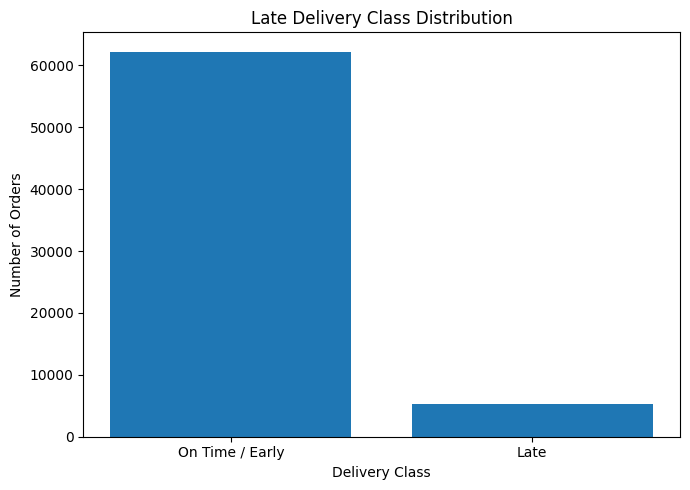

In [15]:
class_labels = {
    0: "On Time / Early",
    1: "Late",
}

chart_data = (
    train[
        "is_late"
    ]
    .value_counts()
    .sort_index()
)

chart_labels = [
    class_labels[
        label
    ]
    for label
    in chart_data.index
]

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.bar(
    chart_labels,
    chart_data.values
)

ax.set_title(
    "Late Delivery Class Distribution"
)

ax.set_ylabel(
    "Number of Orders"
)

ax.set_xlabel(
    "Delivery Class"
)

plt.tight_layout()

plt.savefig(
    CHARTS_DIR
    / "01_class_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Prediction Point and Leakage

For this project, the assumed prediction point is:

**After the order has been approved and before it is handed to the carrier.**

This is a project design decision used to define which information may be available when making a prediction.

Information generated after this prediction point must not be used as predictive model input.

Examples of potential leakage include:

- Actual customer delivery date
- Carrier handoff date
- Review information
- `delay_days`
- Any information directly derived from the final delivery outcome

These columns may still be inspected during EDA, but they must not automatically be used as model features.

In [16]:
known_leakage_columns = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "actual_delivery_days",
    "review_count",
    "review_score_mean",
    "review_score_min",
    "review_score_max",
    "has_review_comment",
    "delay_days",
]

print(
    "Known leakage columns:"
)

for column in known_leakage_columns:
    print(
        "-",
        column
    )

Known leakage columns:
- order_delivered_carrier_date
- order_delivered_customer_date
- actual_delivery_days
- review_count
- review_score_mean
- review_score_min
- review_score_max
- has_review_comment
- delay_days


In [17]:
numerical_eda_features = [
    "item_count",
    "unique_products",
    "unique_sellers",
    "total_item_price",
    "avg_item_price",
    "total_freight_value",
    "avg_freight_value",
    "unique_product_categories",
    "avg_product_weight_g",
    "max_product_weight_g",
    "avg_product_length_cm",
    "avg_product_height_cm",
    "avg_product_width_cm",
    "avg_product_photos_qty",
    "unique_seller_states",
    "payment_records",
    "payment_types_count",
    "payment_total",
    "payment_installments_max",
]

numerical_eda_features = [
    column
    for column
    in numerical_eda_features
    if column in train.columns
]

print(
    "Numerical EDA features:",
    len(numerical_eda_features)
)

print(
    numerical_eda_features
)

Numerical EDA features: 19
['item_count', 'unique_products', 'unique_sellers', 'total_item_price', 'avg_item_price', 'total_freight_value', 'avg_freight_value', 'unique_product_categories', 'avg_product_weight_g', 'max_product_weight_g', 'avg_product_length_cm', 'avg_product_height_cm', 'avg_product_width_cm', 'avg_product_photos_qty', 'unique_seller_states', 'payment_records', 'payment_types_count', 'payment_total', 'payment_installments_max']


In [18]:
numerical_summary = (
    train[
        numerical_eda_features
    ]
    .describe()
    .T
)

display(
    numerical_summary
)

,count,mean,std,min,25%,50%,75%,max
item_count,67529.0,1.142072,0.541640,1.000000,1.00,1.00,1.00,21.00
unique_products,67529.0,1.037702,0.222199,1.000000,1.00,1.00,1.00,7.00
unique_sellers,67529.0,1.012054,0.114815,1.000000,1.00,1.00,1.00,5.00
total_item_price,67529.0,135.888797,205.194019,2.290000,45.90,85.00,149.90,13440.00
avg_item_price,67529.0,124.239070,185.659661,1.514286,41.00,78.97,139.90,6735.00
total_freight_value,67529.0,22.245936,20.002594,0.000000,14.10,16.79,23.70,1002.29
avg_freight_value,67529.0,19.640187,14.382949,0.000000,13.44,16.11,20.29,338.30
unique_product_categories,67529.0,0.988953,0.156398,0.000000,1.00,1.00,1.00,3.00
avg_product_weight_g,67513.0,2171.789992,3866.698263,2.000000,300.00,700.00,1850.00,40425.00
max_product_weight_g,67513.0,2192.133871,3895.302449,2.000000,300.00,700.00,1860.00,40425.00


In [19]:
range_rows = []

for column in numerical_eda_features:

    series = (
        train[column]
        .dropna()
    )

    range_rows.append({
        "feature":
            column,

        "minimum":
            series.min(),

        "maximum":
            series.max(),

        "negative_count":
            int(
                (series < 0)
                .sum()
            ),

        "zero_count":
            int(
                (series == 0)
                .sum()
            ),
    })

range_summary = (
    pd.DataFrame(
        range_rows
    )
)

display(
    range_summary
)

,feature,minimum,maximum,negative_count,zero_count
0,item_count,1.000000,21.00,0,0
1,unique_products,1.000000,7.00,0,0
2,unique_sellers,1.000000,5.00,0,0
3,total_item_price,2.290000,13440.00,0,0
4,avg_item_price,1.514286,6735.00,0,0
5,total_freight_value,0.000000,1002.29,0,10
6,avg_freight_value,0.000000,338.30,0,10
7,unique_product_categories,0.000000,3.00,0,1197
8,avg_product_weight_g,2.000000,40425.00,0,0
9,max_product_weight_g,2.000000,40425.00,0,0


In [20]:
skewness = (
    train[
        numerical_eda_features
    ]
    .skew(
        numeric_only=True
    )
    .sort_values(
        ascending=False
    )
)

skew_summary = (
    skewness
    .rename(
        "skewness"
    )
    .reset_index()
    .rename(
        columns={
            "index":
                "feature"
        }
    )
)

skew_summary[
    "absolute_skew"
] = (
    skew_summary[
        "skewness"
    ]
    .abs()
)

skew_summary[
    "highly_skewed"
] = (
    skew_summary[
        "absolute_skew"
    ] > 1
)

display(
    skew_summary
)

,feature,skewness,absolute_skew,highly_skewed
0,payment_records,22.419509,22.419509,True
1,unique_seller_states,15.177527,15.177527,True
2,total_item_price,10.718895,10.718895,True
3,unique_sellers,10.524938,10.524938,True
4,payment_total,10.149318,10.149318,True
5,total_freight_value,8.581743,8.581743,True
6,item_count,8.107162,8.107162,True
7,avg_item_price,7.802465,7.802465,True
8,unique_products,7.677312,7.677312,True
9,payment_types_count,6.217627,6.217627,True


In [21]:
outlier_rows = []

for column in numerical_eda_features:

    series = (
        train[column]
        .dropna()
    )

    q1 = (
        series
        .quantile(0.25)
    )

    q3 = (
        series
        .quantile(0.75)
    )

    iqr = q3 - q1

    lower_bound = (
        q1
        - 1.5 * iqr
    )

    upper_bound = (
        q3
        + 1.5 * iqr
    )

    outlier_count = int(
        (
            (series < lower_bound)
            |
            (series > upper_bound)
        )
        .sum()
    )

    outlier_rows.append({
        "feature":
            column,

        "q1":
            q1,

        "q3":
            q3,

        "iqr":
            iqr,

        "lower_bound":
            lower_bound,

        "upper_bound":
            upper_bound,

        "outlier_count":
            outlier_count,

        "outlier_pct":
            outlier_count
            / len(series)
            * 100
            if len(series) > 0
            else np.nan,
    })

outlier_summary = pd.DataFrame(
    outlier_rows
)

display(
    outlier_summary
)

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,item_count,1.00,1.00,0.00,1.000,1.000,6758,10.007552
1,unique_products,1.00,1.00,0.00,1.000,1.000,2209,3.271187
2,unique_sellers,1.00,1.00,0.00,1.000,1.000,776,1.149136
3,total_item_price,45.90,149.90,104.00,-110.100,305.900,5362,7.940292
4,avg_item_price,41.00,139.90,98.90,-107.350,288.250,5110,7.567119
5,total_freight_value,14.10,23.70,9.60,-0.300,38.100,6630,9.818004
6,avg_freight_value,13.44,20.29,6.85,3.165,30.565,7104,10.519925
7,unique_product_categories,1.00,1.00,0.00,1.000,1.000,1642,2.431548
8,avg_product_weight_g,300.00,1850.00,1550.00,-2025.000,4175.000,9769,14.469806
9,max_product_weight_g,300.00,1860.00,1560.00,-2040.000,4200.000,9815,14.537941


In [22]:
target_numeric_summary = (
    train
    .groupby(
        "is_late"
    )[
        numerical_eda_features
    ]
    .agg(
        [
            "mean",
            "median",
        ]
    )
    .T
)

display(
    target_numeric_summary
)

is_late                                     0            1
item_count                mean       1.144443     1.114178
                          median     1.000000     1.000000
unique_products           mean       1.039156     1.020605
                          median     1.000000     1.000000
unique_sellers            mean       1.012886     1.002268
                          median     1.000000     1.000000
total_item_price          mean     134.581218   151.272996
                          median    84.990000    92.050000
avg_item_price            mean     122.744287   141.825796
                          median    77.000000    87.720000
total_freight_value       mean      21.956401    25.652437
                          median    16.610000    18.230000
avg_freight_value         mean      19.336592    23.212106
                          median    16.060000    17.740000
unique_product_categories mean       0.989348     0.984310
                          median     1.000000     1.000000
avg_product_weight_g      mean    2140.553668  2539.203558
                          median   700.000000   800.000000
max_product_weight_g      mean    2161.880221  2547.988847
                          median   700.000000   800.000000
avg_product_length_cm     mean      30.512528    31.753848
                          median    25.000000    26.000000
avg_product_height_cm     mean      16.639365    17.505888
                          median    13.000000    13.000000
avg_product_width_cm      mean      23.293316    23.781315
                          median    20.000000    20.000000
avg_product_photos_qty    mean       2.248881     2.202921
                          median     2.000000     1.000000
unique_seller_states      mean       1.005029     1.000567
                          median     1.000000     1.000000
payment_records           mean       1.048330     1.039327
                          median     1.000000     1.000000
payment_types_count       mean       1.024310     1.020609
                          median     1.000000     1.000000
payment_total             mean     156.577540   176.955927
                          median   103.110000   115.900000
payment_installments_max  mean       2.960571     3.139157
                          median     2.000000     2.000000

In [23]:
target_correlations = (
    train[
        numerical_eda_features
        + ["is_late"]
    ]
    .corr(
        numeric_only=True
    )[
        "is_late"
    ]
    .drop(
        "is_late"
    )
    .sort_values(
        key=lambda values:
            values.abs(),
        ascending=False
    )
)

target_correlation_summary = (
    target_correlations
    .rename(
        "correlation_with_is_late"
    )
    .reset_index()
    .rename(
        columns={
            "index":
                "feature"
        }
    )
)

target_correlation_summary[
    "absolute_correlation"
] = (
    target_correlation_summary[
        "correlation_with_is_late"
    ]
    .abs()
)

display(
    target_correlation_summary
)

,feature,correlation_with_is_late,absolute_correlation
0,avg_freight_value,0.072402,0.072402
1,total_freight_value,0.049650,0.049650
2,avg_product_weight_g,0.027706,0.027706
3,avg_item_price,0.027616,0.027616
4,max_product_weight_g,0.026637,0.026637
5,payment_total,0.025551,0.025551
6,unique_sellers,-0.024848,0.024848
7,unique_products,-0.022433,0.022433
8,total_item_price,0.021858,0.021858
9,avg_product_length_cm,0.020386,0.020386


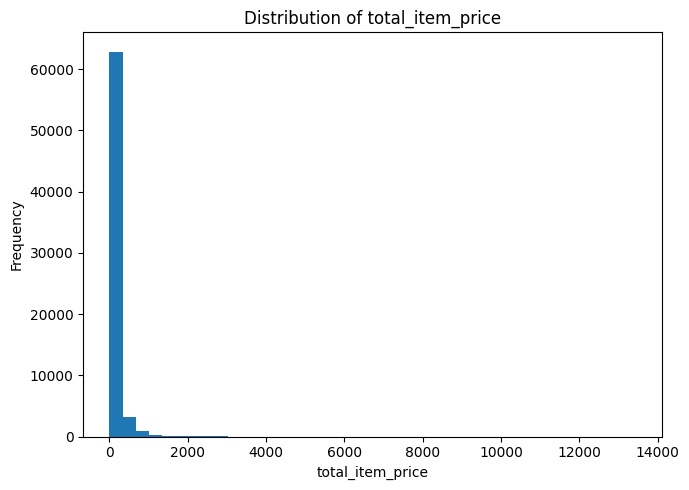

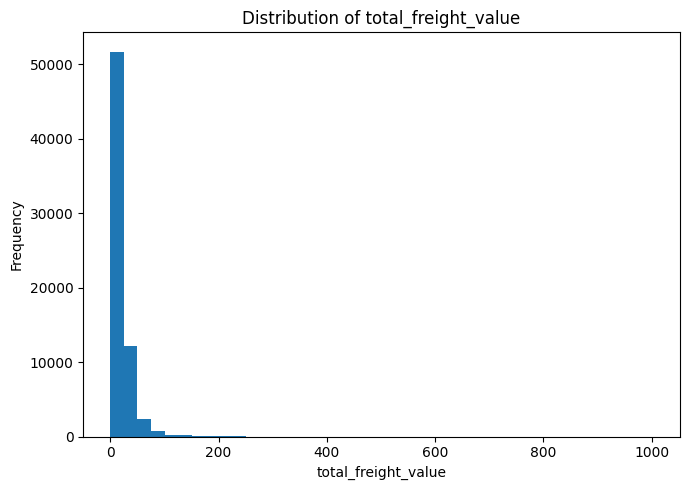

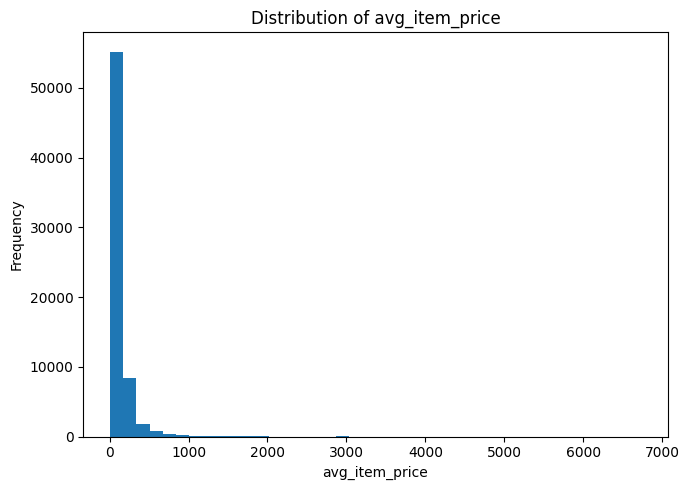

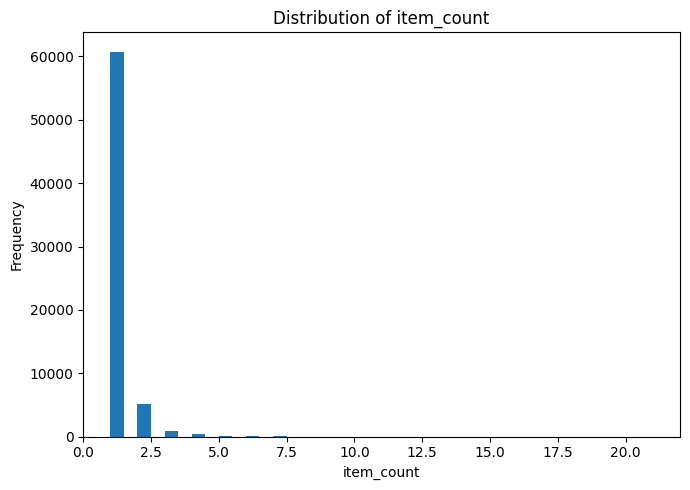

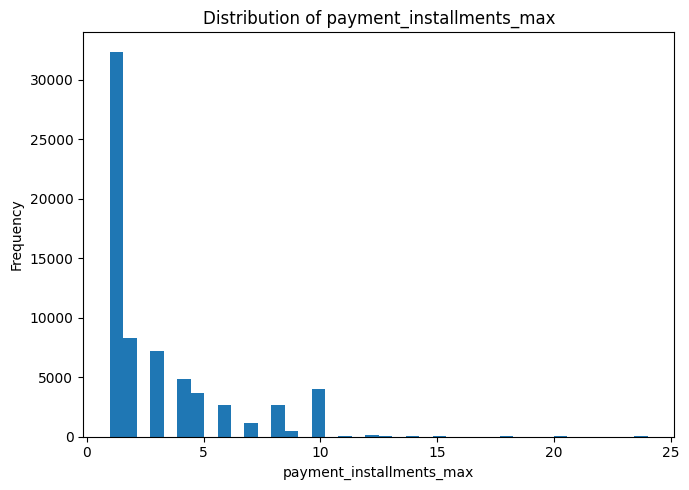

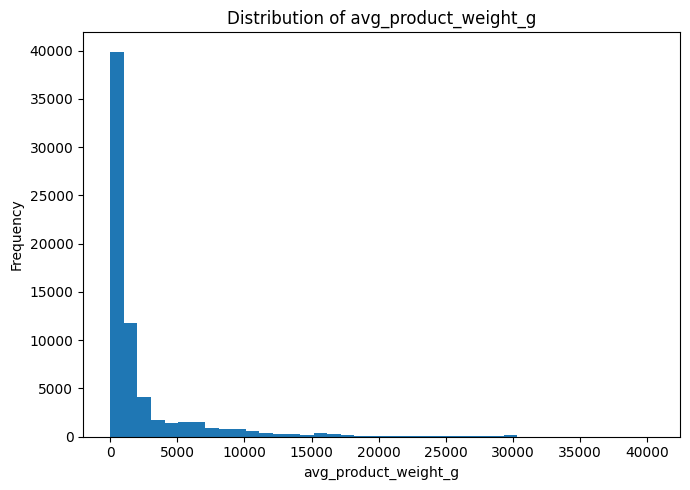

In [24]:
plot_features = [
    "total_item_price",
    "total_freight_value",
    "avg_item_price",
    "item_count",
    "payment_installments_max",
    "avg_product_weight_g",
]

plot_features = [
    column
    for column
    in plot_features
    if column in train.columns
]

for column in plot_features:

    values = (
        train[column]
        .dropna()
    )

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.hist(
        values,
        bins=40
    )

    ax.set_title(
        f"Distribution of {column}"
    )

    ax.set_xlabel(
        column
    )

    ax.set_ylabel(
        "Frequency"
    )

    plt.tight_layout()

    plt.savefig(
        CHARTS_DIR
        / f"numeric_distribution_{column}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

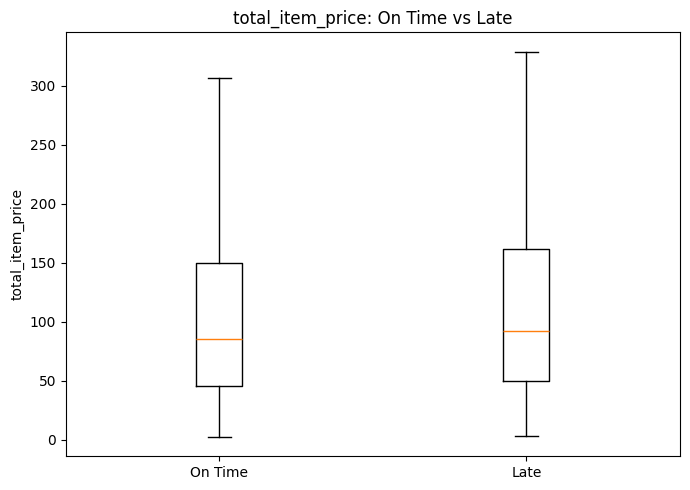

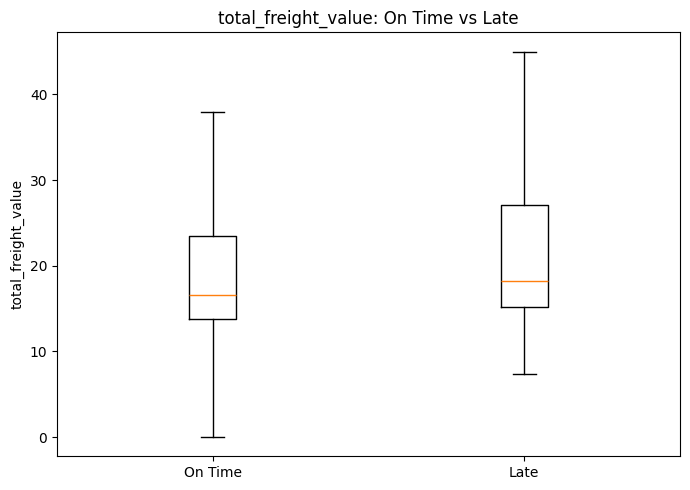

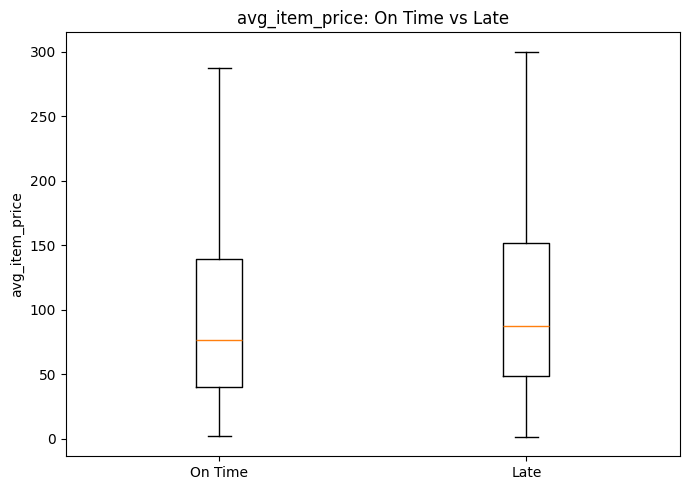

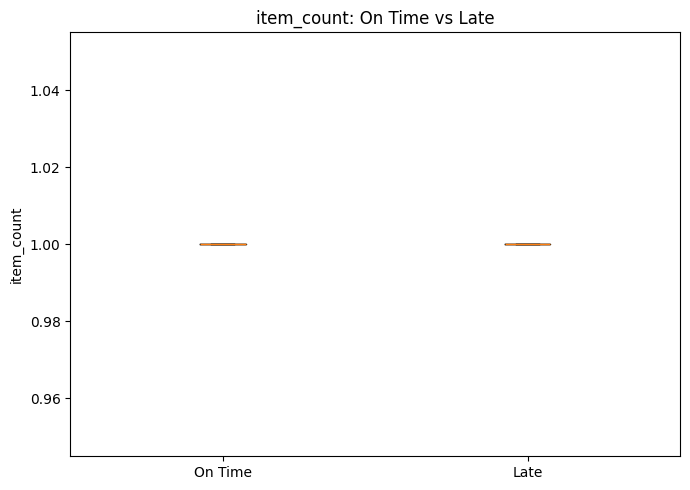

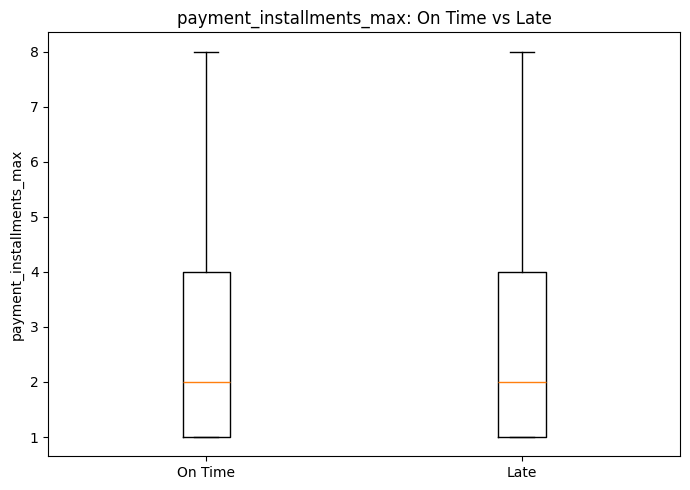

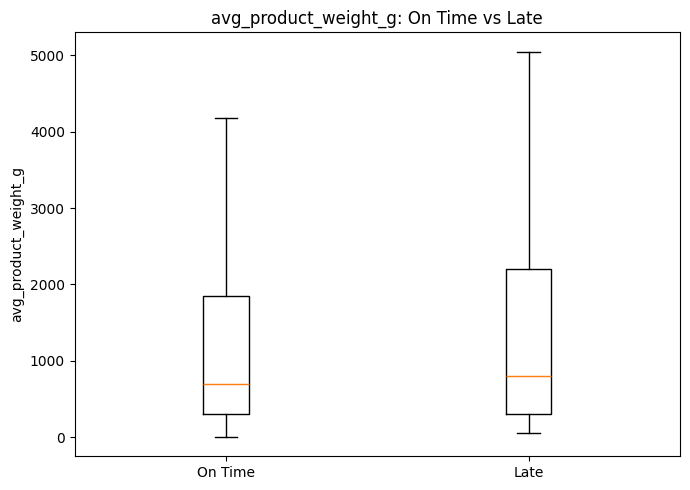

In [25]:
for column in plot_features:

    on_time = (
        train.loc[
            train[
                "is_late"
            ] == 0,
            column,
        ]
        .dropna()
    )

    late = (
        train.loc[
            train[
                "is_late"
            ] == 1,
            column,
        ]
        .dropna()
    )

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.boxplot(
        [
            on_time,
            late,
        ],
        tick_labels=[
            "On Time",
            "Late",
        ],
        showfliers=False
    )

    ax.set_title(
        f"{column}: On Time vs Late"
    )

    ax.set_ylabel(
        column
    )

    plt.tight_layout()

    plt.savefig(
        CHARTS_DIR
        / f"target_comparison_{column}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

In [26]:
categorical_eda_features = [
    "customer_city",
    "customer_state",
    "primary_product_category",
    "primary_seller_state",
    "primary_payment_type",
]

categorical_eda_features = [
    column
    for column
    in categorical_eda_features
    if column in train.columns
]

print(
    "Categorical EDA features:"
)

print(
    categorical_eda_features
)

Categorical EDA features:
['customer_city', 'customer_state', 'primary_product_category', 'primary_seller_state', 'primary_payment_type']


In [27]:
categorical_rows = []

for column in categorical_eda_features:

    value_counts = (
        train[column]
        .value_counts(
            dropna=False
        )
    )

    top_value = (
        value_counts.index[0]
        if len(value_counts) > 0
        else None
    )

    top_count = (
        int(value_counts.iloc[0])
        if len(value_counts) > 0
        else 0
    )

    categorical_rows.append({
        "feature": column,

        "unique_values":
            train[column]
            .nunique(
                dropna=False
            ),

        "missing_count":
            train[column]
            .isna()
            .sum(),

        "missing_pct":
            train[column]
            .isna()
            .mean()
            * 100,

        "top_value":
            top_value,

        "top_count":
            top_count,
    })

categorical_summary = pd.DataFrame(
    categorical_rows
)

display(
    categorical_summary
)

,feature,unique_values,missing_count,missing_pct,top_value,top_count
0,customer_city,3747,0,0.000000,sao paulo,9920
1,customer_state,27,0,0.000000,SP,27204
2,primary_product_category,72,1201,1.778495,bed_bath_table,6630
3,primary_seller_state,22,0,0.000000,SP,47772
4,primary_payment_type,5,1,0.001481,credit_card,51557


In [28]:
rare_category_rows = []

RARE_THRESHOLD = 50

for column in categorical_eda_features:

    counts = (
        train[column]
        .value_counts(
            dropna=False
        )
    )

    rare_counts = (
        counts[
            counts
            < RARE_THRESHOLD
        ]
    )

    rare_category_rows.append({
        "feature":
            column,

        "total_categories":
            len(counts),

        "rare_categories":
            len(rare_counts),

        "rare_orders":
            int(
                rare_counts.sum()
            ),

        "rare_orders_pct":
            rare_counts.sum()
            / len(train)
            * 100,
    })

rare_category_summary = pd.DataFrame(
    rare_category_rows
)

display(
    rare_category_summary
)

,feature,total_categories,rare_categories,rare_orders,rare_orders_pct
0,customer_city,3747,3547,19564,28.971257
1,customer_state,27,1,29,0.042945
2,primary_product_category,72,17,311,0.460543
3,primary_seller_state,22,8,142,0.210280
4,primary_payment_type,5,1,1,0.001481


In [29]:
messy_rows = []

for column in categorical_eda_features:

    series = (
        train[column]
        .dropna()
        .astype(str)
    )

    normalized = (
        series
        .str.strip()
        .str.lower()
    )

    raw_unique = (
        series.nunique()
    )

    normalized_unique = (
        normalized.nunique()
    )

    messy_rows.append({
        "feature":
            column,

        "raw_unique":
            raw_unique,

        "normalized_unique":
            normalized_unique,

        "possible_format_duplicates":
            raw_unique
            - normalized_unique,
    })

messy_category_summary = (
    pd.DataFrame(
        messy_rows
    )
)

display(
    messy_category_summary
)

,feature,raw_unique,normalized_unique,possible_format_duplicates
0,customer_city,3747,3747,0
1,customer_state,27,27,0
2,primary_product_category,71,71,0
3,primary_seller_state,22,22,0
4,primary_payment_type,4,4,0


In [30]:
categorical_target_tables = {}

for column in categorical_eda_features:

    summary = (
        train
        .groupby(
            column,
            dropna=False
        )
        .agg(
            orders=(
                "order_id",
                "count"
            ),

            late_orders=(
                "is_late",
                "sum"
            ),

            late_rate=(
                "is_late",
                "mean"
            ),
        )
        .reset_index()
    )

    summary[
        "late_rate_pct"
    ] = (
        summary[
            "late_rate"
        ]
        * 100
    )

    categorical_target_tables[
        column
    ] = summary

    print(
        f"\n{column}"
    )

    display(
        summary
        .sort_values(
            "orders",
            ascending=False
        )
        .head(20)
    )


customer_city


,customer_city,orders,late_orders,late_rate,late_rate_pct
3276,sao paulo,9920,467,0.047077,4.707661
2874,rio de janeiro,4777,649,0.135859,13.585933
407,belo horizonte,1869,109,0.058320,5.831996
502,brasilia,1395,91,0.065233,6.523297
1037,curitiba,1020,44,0.043137,4.313725
2699,porto alegre,975,122,0.125128,12.512821
638,campinas,967,94,0.097208,9.720786
2959,salvador,823,138,0.167679,16.767922
1391,guarulhos,724,34,0.046961,4.696133
3126,sao bernardo do campo,622,38,0.061093,6.109325



customer_state


,customer_state,orders,late_orders,late_rate,late_rate_pct
25,SP,27204,1256,0.046170,4.616968
18,RJ,8965,1356,0.151255,15.125488
10,MG,8129,426,0.052405,5.240497
22,RS,3912,290,0.074131,7.413088
17,PR,3461,160,0.046229,4.622941
23,SC,2576,266,0.103261,10.326087
4,BA,2307,301,0.130472,13.047248
7,ES,1445,172,0.119031,11.903114
8,GO,1409,109,0.077360,7.735983
6,DF,1404,91,0.064815,6.481481



primary_product_category


,primary_product_category,orders,late_orders,late_rate,late_rate_pct
7,bed_bath_table,6630,603,0.090950,9.095023
65,sports_leisure,5594,420,0.075080,7.508044
43,health_beauty,5377,441,0.082016,8.201599
15,computers_accessories,4781,355,0.074252,7.425225
39,furniture_decor,4537,375,0.082654,8.265374
49,housewares,3506,221,0.063035,6.303480
70,watches_gifts,3257,301,0.092416,9.241633
68,telephony,3066,252,0.082192,8.219178
69,toys,2972,208,0.069987,6.998654
20,cool_stuff,2932,174,0.059345,5.934516



primary_seller_state


,primary_seller_state,orders,late_orders,late_rate,late_rate_pct
21,SP,47772,4074,0.085280,8.528008
7,MG,5663,313,0.055271,5.527106
14,PR,5385,347,0.064438,6.443825
15,RJ,2702,235,0.086973,8.697261
19,SC,2589,140,0.054075,5.407493
18,RS,1287,47,0.036519,3.651904
3,DF,587,35,0.059625,5.962521
1,BA,409,24,0.058680,5.867971
5,GO,302,12,0.039735,3.973510
4,ES,253,17,0.067194,6.719368



primary_payment_type


,primary_payment_type,orders,late_orders,late_rate,late_rate_pct
1,credit_card,51557,4010,0.077778,7.777799
0,boleto,13901,1133,0.081505,8.150493
3,voucher,1372,92,0.067055,6.705539
2,debit_card,698,54,0.077364,7.736390
4,NaN,1,1,1.000000,100.000000


In [31]:
customer_state_crosstab = (
    pd.crosstab(
        train[
            "customer_state"
        ],
        train[
            "is_late"
        ],
        normalize="index"
    )
    * 100
)

payment_type_crosstab = (
    pd.crosstab(
        train[
            "primary_payment_type"
        ],
        train[
            "is_late"
        ],
        normalize="index"
    )
    * 100
)

print(
    "Customer state crosstab:"
)

display(
    customer_state_crosstab
)

print(
    "\nPayment type crosstab:"
)

display(
    payment_type_crosstab
)

Customer state crosstab:


is_late,0,1
customer_state,,
AC,95.454545,4.545455
AL,75.167785,24.832215
AM,96.190476,3.809524
AP,96.078431,3.921569
BA,86.952752,13.047248
CE,83.333333,16.666667
DF,93.518519,6.481481
ES,88.096886,11.903114
GO,92.264017,7.735983



Payment type crosstab:


is_late,0,1
primary_payment_type,,
boleto,91.849507,8.150493
credit_card,92.222201,7.777799
debit_card,92.263610,7.736390
voucher,93.294461,6.705539


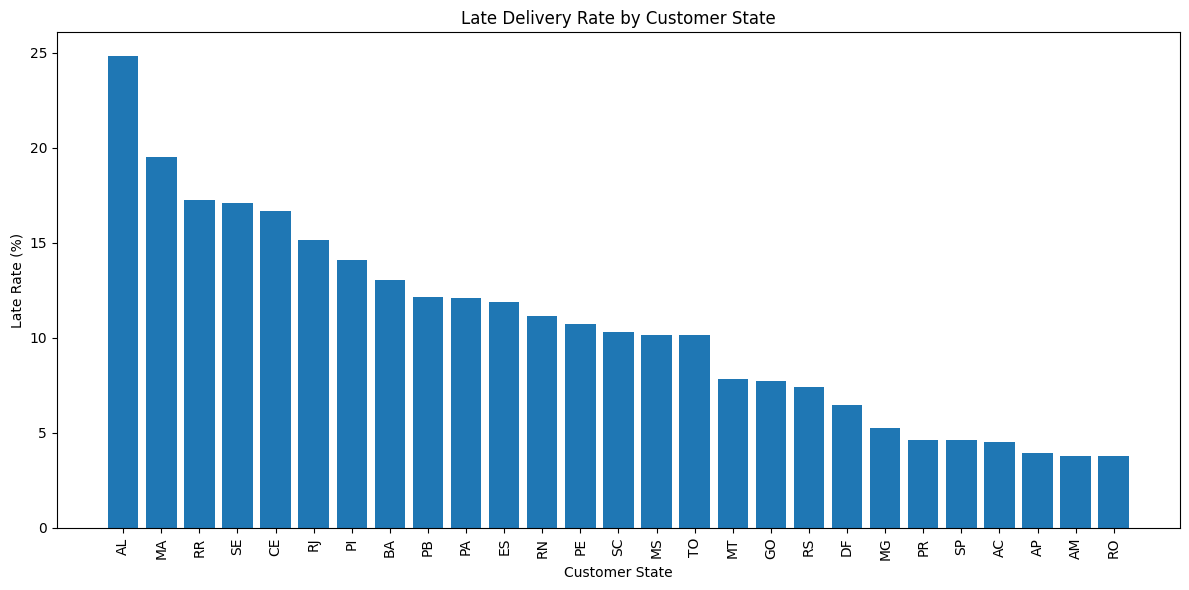

In [32]:
customer_state_summary = (
    categorical_target_tables[
        "customer_state"
    ]
    .sort_values(
        "late_rate_pct",
        ascending=False
    )
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.bar(
    customer_state_summary[
        "customer_state"
    ].astype(str),
    customer_state_summary[
        "late_rate_pct"
    ]
)

ax.set_title(
    "Late Delivery Rate by Customer State"
)

ax.set_xlabel(
    "Customer State"
)

ax.set_ylabel(
    "Late Rate (%)"
)

ax.tick_params(
    axis="x",
    rotation=90
)

plt.tight_layout()

plt.savefig(
    CHARTS_DIR
    / "customer_state_late_rate.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [33]:
train[
    "purchase_month"
] = (
    train[
        "order_purchase_timestamp"
    ]
    .dt.to_period(
        "M"
    )
)

train[
    "purchase_weekday"
] = (
    train[
        "order_purchase_timestamp"
    ]
    .dt.day_name()
)

train[
    "purchase_hour"
] = (
    train[
        "order_purchase_timestamp"
    ]
    .dt.hour
)

train[
    "estimated_delivery_days"
] = (
    train[
        "order_estimated_delivery_date"
    ]
    - train[
        "order_purchase_timestamp"
    ]
).dt.total_seconds() / 86400

train[
    "approval_hours"
] = (
    train[
        "order_approved_at"
    ]
    - train[
        "order_purchase_timestamp"
    ]
).dt.total_seconds() / 3600

print(
    "Time features created."
)

Time features created.


In [34]:
train[
    "actual_delivery_days"
] = (
    train[
        "order_delivered_customer_date"
    ]
    - train[
        "order_purchase_timestamp"
    ]
).dt.total_seconds() / 86400

time_duration_features = [
    "estimated_delivery_days",
    "actual_delivery_days",
    "approval_hours",
]

time_duration_summary = (
    train[
        time_duration_features
    ]
    .describe()
    .T
)

display(
    time_duration_summary
)

,count,mean,std,min,25%,50%,75%,max
estimated_delivery_days,67529.0,24.595253,8.018400,7.005127,19.543333,23.621331,28.564965,155.135463
actual_delivery_days,67529.0,13.824217,10.248897,0.533414,7.450845,11.475266,17.189155,209.628611
approval_hours,67515.0,9.930969,20.421087,0.000000,0.205278,0.307500,13.447639,741.443611


In [35]:
monthly_summary = (
    train
    .groupby(
        "purchase_month"
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),

        late_orders=(
            "is_late",
            "sum"
        ),

        late_rate=(
            "is_late",
            "mean"
        ),
    )
    .reset_index()
)

monthly_summary[
    "late_rate_pct"
] = (
    monthly_summary[
        "late_rate"
    ]
    * 100
)

display(
    monthly_summary
)

MIN_MONTH_ORDERS = 100

monthly_summary_reliable = (
    monthly_summary.loc[
        monthly_summary[
            "orders"
        ] >= MIN_MONTH_ORDERS
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Months used for reliable temporal comparison:"
)

display(
    monthly_summary_reliable
)

,purchase_month,orders,late_orders,late_rate,late_rate_pct
0,2016-09,1,1,1.000000,100.000000
1,2016-10,265,2,0.007547,0.754717
2,2016-12,1,0,0.000000,0.000000
3,2017-01,750,22,0.029333,2.933333
4,2017-02,1653,49,0.029643,2.964307
5,2017-03,2546,116,0.045562,4.556167
6,2017-04,2303,151,0.065567,6.556665
7,2017-05,3545,106,0.029901,2.990127
8,2017-06,3135,95,0.030303,3.030303
9,2017-07,3872,108,0.027893,2.789256


Months used for reliable temporal comparison:


,purchase_month,orders,late_orders,late_rate,late_rate_pct
0,2016-10,265,2,0.007547,0.754717
1,2017-01,750,22,0.029333,2.933333
2,2017-02,1653,49,0.029643,2.964307
3,2017-03,2546,116,0.045562,4.556167
4,2017-04,2303,151,0.065567,6.556665
5,2017-05,3545,106,0.029901,2.990127
6,2017-06,3135,95,0.030303,3.030303
7,2017-07,3872,108,0.027893,2.789256
8,2017-08,4193,122,0.029096,2.909611
9,2017-09,4150,182,0.043855,4.385542


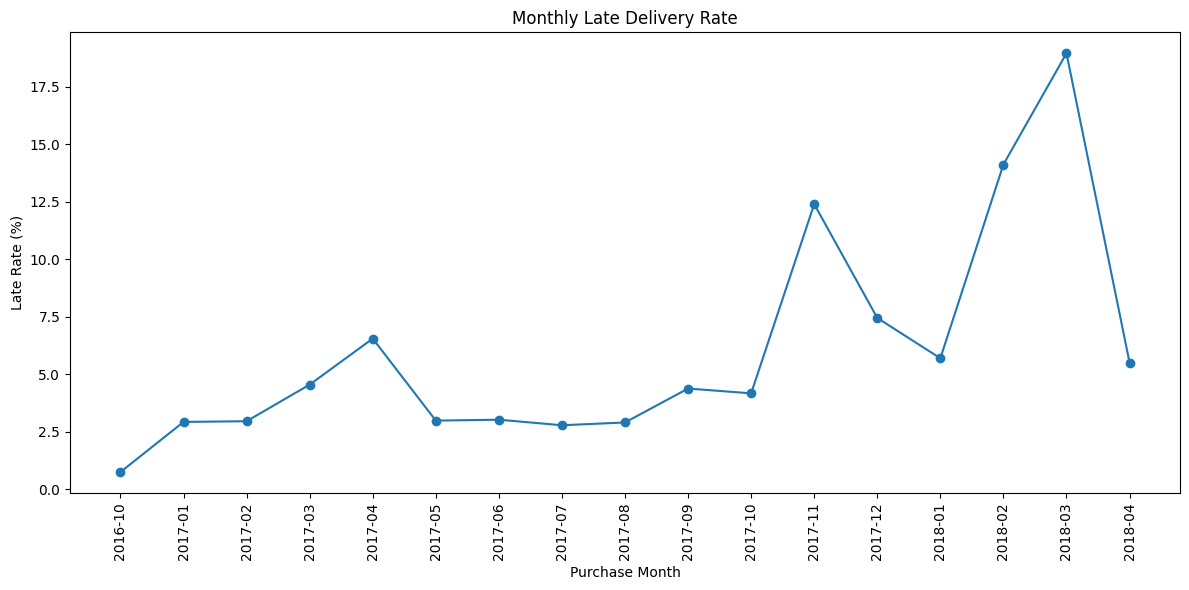

In [36]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    monthly_summary_reliable[
        "purchase_month"
    ].astype(str),
    monthly_summary_reliable[
        "late_rate_pct"
    ],
    marker="o"
)

ax.set_title(
    "Monthly Late Delivery Rate"
)

ax.set_xlabel(
    "Purchase Month"
)

ax.set_ylabel(
    "Late Rate (%)"
)

ax.tick_params(
    axis="x",
    rotation=90
)

plt.tight_layout()

plt.savefig(
    CHARTS_DIR
    / "monthly_late_rate.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [37]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_summary = (
    train
    .groupby(
        "purchase_weekday"
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),

        late_orders=(
            "is_late",
            "sum"
        ),

        late_rate=(
            "is_late",
            "mean"
        ),
    )
    .reindex(
        weekday_order
    )
    .reset_index()
)

weekday_summary[
    "late_rate_pct"
] = (
    weekday_summary[
        "late_rate"
    ]
    * 100
)

display(
    weekday_summary
)

,purchase_weekday,orders,late_orders,late_rate,late_rate_pct
0,Monday,10734,922,0.085895,8.589529
1,Tuesday,10729,857,0.079877,7.987697
2,Wednesday,10339,778,0.075249,7.524906
3,Thursday,10005,725,0.072464,7.246377
4,Friday,9884,808,0.081748,8.174828
5,Saturday,7593,599,0.078888,7.888845
6,Sunday,8245,601,0.072893,7.289266


In [38]:
hour_summary = (
    train
    .groupby(
        "purchase_hour"
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),

        late_orders=(
            "is_late",
            "sum"
        ),

        late_rate=(
            "is_late",
            "mean"
        ),
    )
    .reset_index()
)

hour_summary[
    "late_rate_pct"
] = (
    hour_summary[
        "late_rate"
    ]
    * 100
)

display(
    hour_summary
)

,purchase_hour,orders,late_orders,late_rate,late_rate_pct
0,0,1661,144,0.086695,8.669476
1,1,837,69,0.082437,8.243728
2,2,370,26,0.070270,7.027027
3,3,186,9,0.048387,4.838710
4,4,136,8,0.058824,5.882353
5,5,134,8,0.059701,5.970149
6,6,318,22,0.069182,6.918239
7,7,806,59,0.073201,7.320099
8,8,1951,146,0.074833,7.483342
9,9,3211,227,0.070694,7.069449


In [39]:
fixed_holiday_month_days = [
    (1, 1),
    (4, 21),
    (5, 1),
    (9, 7),
    (10, 12),
    (11, 2),
    (11, 15),
    (12, 25),
]

training_years = (
    train[
        "order_purchase_timestamp"
    ]
    .dt.year
    .dropna()
    .astype(int)
    .unique()
)

fixed_holidays = set()

for year in training_years:

    for month, day in fixed_holiday_month_days:

        fixed_holidays.add(
            pd.Timestamp(
                year=year,
                month=month,
                day=day
            )
        )

purchase_dates = (
    train[
        "order_purchase_timestamp"
    ]
    .dt.normalize()
)

train[
    "is_fixed_national_holiday"
] = (
    purchase_dates
    .isin(
        fixed_holidays
    )
    .astype(
        "int8"
    )
)

holiday_summary = (
    train
    .groupby(
        "is_fixed_national_holiday"
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),

        late_orders=(
            "is_late",
            "sum"
        ),

        late_rate=(
            "is_late",
            "mean"
        ),
    )
    .reset_index()
)

holiday_summary[
    "late_rate_pct"
] = (
    holiday_summary[
        "late_rate"
    ]
    * 100
)

display(
    holiday_summary
)

,is_fixed_national_holiday,orders,late_orders,late_rate,late_rate_pct
0,0,66668,5253,0.078793,7.879342
1,1,861,37,0.042973,4.297329


In [40]:
earth_radius_km = 6371.0

customer_lat_rad = np.radians(
    train[
        "customer_lat"
    ]
)

customer_lng_rad = np.radians(
    train[
        "customer_lng"
    ]
)

seller_lat_rad = np.radians(
    train[
        "avg_seller_lat"
    ]
)

seller_lng_rad = np.radians(
    train[
        "avg_seller_lng"
    ]
)

delta_lat = (
    seller_lat_rad
    - customer_lat_rad
)

delta_lng = (
    seller_lng_rad
    - customer_lng_rad
)

haversine_a = (
    np.sin(
        delta_lat / 2
    ) ** 2
    +
    np.cos(
        customer_lat_rad
    )
    *
    np.cos(
        seller_lat_rad
    )
    *
    np.sin(
        delta_lng / 2
    ) ** 2
)

haversine_c = (
    2
    * np.arcsin(
        np.sqrt(
            haversine_a
        )
    )
)

train[
    "customer_seller_distance_km"
] = (
    earth_radius_km
    * haversine_c
)

display(
    train[
        "customer_seller_distance_km"
    ]
    .describe()
)

count    67185.000000
mean       614.426215
std        594.873281
min          0.000000
25%        219.185525
50%        448.211513
75%        810.631242
max       5338.619521
Name: customer_seller_distance_km, dtype: float64

In [41]:
distance_target_summary = (
    train
    .groupby(
        "is_late"
    )[
        "customer_seller_distance_km"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
        ]
    )
    .reset_index()
)

display(
    distance_target_summary
)

,is_late,count,mean,median
0,0,61929,599.229219,437.882052
1,1,5256,793.485335,560.083631


In [42]:
train[
    "same_customer_seller_state"
] = pd.Series(
    pd.NA,
    index=train.index,
    dtype="Int8"
)

valid_state_rows = (
    train[
        "customer_state"
    ].notna()
    &
    train[
        "primary_seller_state"
    ].notna()
)

train.loc[
    valid_state_rows,
    "same_customer_seller_state"
] = (
    train.loc[
        valid_state_rows,
        "customer_state"
    ]
    ==
    train.loc[
        valid_state_rows,
        "primary_seller_state"
    ]
).astype(
    "int8"
)

same_state_summary = (
    train
    .groupby(
        "same_customer_seller_state",
        dropna=False
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),

        late_orders=(
            "is_late",
            "sum"
        ),

        late_rate=(
            "is_late",
            "mean"
        ),
    )
    .reset_index()
)

same_state_summary[
    "late_rate_pct"
] = (
    same_state_summary[
        "late_rate"
    ]
    * 100
)

display(
    same_state_summary
)

,same_customer_seller_state,orders,late_orders,late_rate,late_rate_pct
0,0,44473,4265,0.095901,9.590088
1,1,23056,1025,0.044457,4.445697


In [43]:
zip_summary = (
    train
    .groupby(
        "customer_zip_code_prefix",
        dropna=False
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),

        late_orders=(
            "is_late",
            "sum"
        ),

        late_rate=(
            "is_late",
            "mean"
        ),
    )
    .reset_index()
)

zip_summary[
    "late_rate_pct"
] = (
    zip_summary[
        "late_rate"
    ]
    * 100
)

reliable_zip_summary = (
    zip_summary.loc[
        zip_summary[
            "orders"
        ] >= 50
    ]
    .sort_values(
        "late_rate_pct",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "All ZIP prefixes:"
)

display(
    zip_summary.head()
)

print(
    "\nZIP prefixes with at least 50 orders:"
)

display(
    reliable_zip_summary.head(30)
)

All ZIP prefixes:


,customer_zip_code_prefix,orders,late_orders,late_rate,late_rate_pct
0,1004,1,0,0.0,0.0
1,1005,3,0,0.0,0.0
2,1006,2,0,0.0,0.0
3,1007,1,0,0.0,0.0
4,1008,1,0,0.0,0.0



ZIP prefixes with at least 50 orders:


,customer_zip_code_prefix,orders,late_orders,late_rate,late_rate_pct
0,22793,89,32,0.359551,35.955056
1,20540,53,10,0.188679,18.867925
2,20550,55,10,0.181818,18.181818
3,24220,82,14,0.170732,17.073171
4,20520,53,8,0.150943,15.094340
5,22790,113,17,0.150442,15.044248
6,22775,80,12,0.150000,15.000000
7,29101,73,10,0.136986,13.698630
8,28970,59,8,0.135593,13.559322
9,22795,54,7,0.129630,12.962963


In [44]:
correlation_features = [
    *numerical_eda_features,
    "estimated_delivery_days",
    "approval_hours",
    "customer_seller_distance_km",
    "same_customer_seller_state",
    "is_fixed_national_holiday",
    "is_late",
]

correlation_features = list(
    dict.fromkeys(
        [
            column
            for column
            in correlation_features
            if column in train.columns
        ]
    )
)

correlation_matrix = (
    train[
        correlation_features
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .corr()
)

display(
    correlation_matrix
)

,item_count,unique_products,unique_sellers,total_item_price,avg_item_price,total_freight_value,avg_freight_value,unique_product_categories,avg_product_weight_g,max_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,avg_product_photos_qty,unique_seller_states,payment_records,payment_types_count,payment_total,payment_installments_max,estimated_delivery_days,approval_hours,customer_seller_distance_km,same_customer_seller_state,is_fixed_national_holiday,is_late
item_count,1.000000,0.457147,0.260594,0.155734,-0.059678,0.475095,-0.023693,0.109256,-0.006807,0.006770,0.011793,0.010157,-0.005543,-0.050007,0.166868,-0.003911,-0.008107,0.193596,0.065074,0.011731,0.027797,-0.014069,0.005153,-0.000079,-0.015014
unique_products,0.457147,1.000000,0.562650,0.056323,-0.039761,0.207962,-0.023401,0.234852,-0.018912,0.008969,-0.004515,-0.032137,0.005747,-0.024670,0.353870,0.007676,0.005592,0.073448,0.068330,0.013971,0.002843,-0.014531,0.006006,0.005666,-0.022433
unique_sellers,0.260594,0.562650,1.000000,0.039233,-0.020530,0.121991,-0.009765,0.304301,-0.009699,0.020596,0.004071,-0.009665,0.002996,-0.013652,0.638518,0.017610,0.013013,0.049131,0.055882,0.012828,0.003965,-0.012644,-0.004874,0.008762,-0.024848
total_item_price,0.155734,0.056323,0.039233,1.000000,0.928929,0.414528,0.399651,0.019735,0.330849,0.332146,0.134127,0.234202,0.170351,0.032236,0.030645,0.000035,-0.008799,0.996353,0.310635,0.068487,0.026324,0.078422,-0.059669,-0.000771,0.021858
avg_item_price,-0.059678,-0.039761,-0.020530,0.928929,1.000000,0.292043,0.422300,-0.006058,0.342557,0.339848,0.133421,0.242522,0.176129,0.048241,-0.010751,0.000692,-0.006666,0.916862,0.315015,0.067520,0.013907,0.083596,-0.061524,-0.001006,0.027616
total_freight_value,0.475095,0.207962,0.121991,0.414528,0.292043,1.000000,0.788951,0.067390,0.512447,0.520613,0.244391,0.336548,0.261066,-0.009831,0.082397,0.000186,-0.006113,0.490471,0.198660,0.250897,0.039349,0.313290,-0.246617,0.001626,0.049650
avg_freight_value,-0.023693,-0.023401,-0.009765,0.399651,0.422300,0.788951,1.000000,0.015054,0.639494,0.636855,0.295808,0.407929,0.331328,0.022330,-0.003135,0.002041,-0.002626,0.456530,0.212076,0.305028,0.026066,0.400710,-0.307579,0.002195,0.072402
unique_product_categories,0.109256,0.234852,0.304301,0.019735,-0.006058,0.067390,0.015054,1.000000,0.013527,0.025662,0.039728,0.017290,0.042343,-0.005783,0.195988,0.007754,0.002423,0.025288,0.038423,0.018436,0.001999,0.005865,-0.008646,0.006339,-0.008655
avg_product_weight_g,-0.006807,-0.018912,-0.009699,0.330849,0.342557,0.512447,0.639494,0.013527,1.000000,0.997218,0.450655,0.582189,0.508151,0.029492,-0.008137,0.009582,-0.003985,0.364770,0.197268,0.074647,0.009356,-0.005339,-0.000132,0.001906,0.027706
max_product_weight_g,0.006770,0.008969,0.020596,0.332146,0.339848,0.520613,0.636855,0.025662,0.997218,1.000000,0.450130,0.580857,0.507238,0.029097,0.010562,0.009748,-0.004046,0.366774,0.199124,0.074948,0.009794,-0.005509,-0.000127,0.002700,0.026637


In [45]:
column_profile.to_csv(
    EDA_DIR
    / "column_profile.csv",
    index=False
)

missing_summary.to_csv(
    EDA_DIR
    / "missing_summary.csv",
    index=False
)

missing_impact.to_csv(
    EDA_DIR
    / "missing_impact.csv",
    index=False
)

class_summary.to_csv(
    EDA_DIR
    / "class_summary.csv",
    index=False
)

numerical_summary.to_csv(
    EDA_DIR
    / "numerical_summary.csv"
)

range_summary.to_csv(
    EDA_DIR
    / "range_summary.csv",
    index=False
)

skew_summary.to_csv(
    EDA_DIR
    / "skewness_summary.csv",
    index=False
)

outlier_summary.to_csv(
    EDA_DIR
    / "outlier_summary.csv",
    index=False
)

target_numeric_summary.to_csv(
    EDA_DIR
    / "target_numeric_summary.csv"
)

target_correlation_summary.to_csv(
    EDA_DIR
    / "target_correlation_summary.csv",
    index=False
)

categorical_summary.to_csv(
    EDA_DIR
    / "categorical_summary.csv",
    index=False
)

rare_category_summary.to_csv(
    EDA_DIR
    / "rare_category_summary.csv",
    index=False
)

messy_category_summary.to_csv(
    EDA_DIR
    / "messy_category_summary.csv",
    index=False
)

monthly_summary.to_csv(
    EDA_DIR
    / "monthly_summary.csv",
    index=False
)

weekday_summary.to_csv(
    EDA_DIR
    / "weekday_summary.csv",
    index=False
)

hour_summary.to_csv(
    EDA_DIR
    / "hour_summary.csv",
    index=False
)

holiday_summary.to_csv(
    EDA_DIR
    / "holiday_summary.csv",
    index=False
)

time_duration_summary.to_csv(
    EDA_DIR
    / "time_duration_summary.csv"
)

distance_target_summary.to_csv(
    EDA_DIR
    / "distance_target_summary.csv",
    index=False
)

same_state_summary.to_csv(
    EDA_DIR
    / "same_state_summary.csv",
    index=False
)

zip_summary.to_csv(
    EDA_DIR
    / "zip_summary.csv",
    index=False
)

reliable_zip_summary.to_csv(
    EDA_DIR
    / "reliable_zip_summary.csv",
    index=False
)

customer_state_crosstab.to_csv(
    EDA_DIR
    / "customer_state_crosstab.csv"
)

payment_type_crosstab.to_csv(
    EDA_DIR
    / "payment_type_crosstab.csv"
)

correlation_matrix.to_csv(
    EDA_DIR
    / "correlation_matrix.csv"
)


for (
    column,
    summary
) in categorical_target_tables.items():

    summary.to_csv(
        EDA_DIR
        / f"categorical_target_{column}.csv",
        index=False
    )

monthly_summary_reliable.to_csv(
    EDA_DIR
    / "monthly_summary_reliable.csv",
    index=False
)

print(
    "EDA tables saved successfully."
)

EDA tables saved successfully.


In [46]:
top_missing = (
    missing_summary
    .head(5)
)

top_correlations = (
    target_correlation_summary
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .head(5)
)

top_skewed = (
    skew_summary
    .sort_values(
        "absolute_skew",
        ascending=False
    )
    .head(5)
)


if not top_missing.empty:

    top_missing_text = "; ".join(
        (
            f"{row['column']} "
            f"({row['missing_pct']:.2f}%)"
        )
        for _, row
        in top_missing.iterrows()
    )

else:

    top_missing_text = (
        "No missing values"
    )


if not top_correlations.empty:

    top_correlation_text = "; ".join(
        (
            f"{row['feature']} "
            f"({row['correlation_with_is_late']:.3f})"
        )
        for _, row
        in top_correlations.iterrows()
    )

else:

    top_correlation_text = (
        "None"
    )


if not top_skewed.empty:

    top_skewed_text = "; ".join(
        (
            f"{row['feature']} "
            f"({row['skewness']:.2f})"
        )
        for _, row
        in top_skewed.iterrows()
    )

else:

    top_skewed_text = (
        "None"
    )


constant_text = (
    ", ".join(
        constant_columns
    )
    if constant_columns
    else "None"
)


late_rate_pct = (
    train[
        "is_late"
    ].mean()
    * 100
)


highest_late_month_row = (
    monthly_summary_reliable.loc[
        monthly_summary_reliable[
            "late_rate_pct"
        ].idxmax()
    ]
)

highest_late_month = str(
    highest_late_month_row[
        "purchase_month"
    ]
)

highest_month_late_rate = (
    highest_late_month_row[
        "late_rate_pct"
    ]
)


findings_lines = [
    "# EDA Findings Summary",
    "",
    "## Dataset",
    (
        f"- Training rows: "
        f"{len(train):,}"
    ),
    (
        f"- Original training columns: "
        f"{input_column_count}"
    ),
    (
        f"- Training late-delivery rate: "
        f"{late_rate_pct:.2f}%"
    ),
    "",
    "## Data Quality",
    (
        f"- Constant columns: "
        f"{constant_text}"
    ),
    (
        f"- Highest missingness: "
        f"{top_missing_text}"
    ),
    "",
    "## Numerical Features",
    (
        "- Strongest numerical correlations "
        "with the target: "
        f"{top_correlation_text}"
    ),
    (
        "- Most skewed numerical variables: "
        f"{top_skewed_text}"
    ),
    (
        "- IQR-based outliers were measured "
        "but were not automatically removed."
    ),
    "",
    "## Temporal Patterns",
    (
        f"- Highest observed monthly late rate: "
        f"{highest_late_month} "
        f"({highest_month_late_rate:.2f}%)."
    ),
    (
        "- Late-delivery rates vary across "
        "time periods, supporting the use of "
        "a chronological train/validation/test split."
    ),
    (
        "- Purchase weekday, purchase hour, "
        "approval time, expected delivery duration, "
        "and fixed national holidays were evaluated."
    ),
    "",
    "## Geography",
    (
        "- Customer state, seller state, "
        "ZIP prefix, same-state indicator, and "
        "customer-seller distance were evaluated."
    ),
    (
        "- ZIP prefixes are high-cardinality, "
        "so reliable ZIP-level comparisons were "
        "restricted to prefixes with at least "
        "50 training orders."
    ),
    "",
    "## Leakage",
    (
        "- Post-prediction information such as "
        "actual delivery dates, carrier handoff "
        "dates, reviews, and delay_days must not "
        "be used as model input."
    ),
    "",
    "## Feature Engineering Direction",
    (
        "- Consider engineered temporal features "
        "such as purchase month, weekday, hour, "
        "estimated delivery duration, and approval delay."
    ),
    (
        "- Consider geographic features such as "
        "customer-seller distance and whether customer "
        "and seller are in the same state."
    ),
    (
        "- High-cardinality categorical variables "
        "will require careful encoding or grouping."
    ),
    (
        "- Strongly skewed numerical features may "
        "benefit from robust transformations depending "
        "on the selected model."
    ),
    (
        "- Missing-value handling must be learned "
        "from the training data only in Notebook 05."
    ),
]


FINDINGS_PATH = (
    EDA_DIR
    / "findings_summary.md"
)

FINDINGS_PATH.write_text(
    "\n".join(
        findings_lines
    ),
    encoding="utf-8"
)

print(
    "Findings summary saved:"
)

print(
    FINDINGS_PATH
)

Findings summary saved:
G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\04_eda\findings_summary.md


In [47]:
print(
    "=" * 65
)

print(
    "NOTEBOOK 04 COMPLETE"
)

print(
    "=" * 65
)

print(
    f"Training rows       : {len(train):,}"
)

print(
    f"Late-delivery rate  : "
    f"{train['is_late'].mean() * 100:.2f}%"
)

print(
    f"Charts directory    : {CHARTS_DIR}"
)

print(
    f"Findings summary    : {FINDINGS_PATH}"
)

print(
    "\nEDA artifact files:"
)

for path in sorted(
    EDA_DIR.rglob("*")
):

    if path.is_file():

        print(
            "-",
            path.relative_to(
                EDA_DIR
            )
        )

NOTEBOOK 04 COMPLETE
Training rows       : 67,529
Late-delivery rate  : 7.83%
Charts directory    : G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\04_eda\charts
Findings summary    : G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\04_eda\findings_summary.md

EDA artifact files:
- categorical_summary.csv
- categorical_target_customer_city.csv
- categorical_target_customer_state.csv
- categorical_target_primary_payment_type.csv
- categorical_target_primary_product_category.csv
- categorical_target_primary_seller_state.csv
- charts\01_class_distribution.png
- charts\customer_state_late_rate.png
- charts\monthly_late_rate.png
- charts\numeric_distribution_avg_item_price.png
- charts\numeric_distribution_avg_product_weight_g.png
- charts\numeric_distribution_item_count.png
- charts\numeric_distribution_payment_installments_max.png
- charts\numeric_distribution_total_freight_value.png
- charts\numeric_distribution_total_item_price.png
- charts\target_comparison_avg_item_price.png
- charts\target_co